In [20]:
'''
Code for testing a CIC Decimator module, to have an HDL implementation
'''

import numpy as np
import scipy
import matplotlib.pyplot as plt
import time

In [8]:
# Creating a fixed point implementation as a reference for the HDL implementation

def float_to_Q1_15(data: float) -> int:
    '''
    Takes in a floating point number and returns that numbers repersenation in Q.15 fixed point
    Args:
        data: float - number to be converted
    Returns:
        q1_15_num: int - number converted to Q1.15
    '''

    q1_15_num = round(data * (2**15))

    if q1_15_num > 32767: q1_15_num = 32767
    elif q1_15_num < -32768: q1_15_num = -32768

    return q1_15_num

def float_array_to_q1_15(data: np.ndarray) -> np.ndarray:
    '''
    Takes in an array of floating points and returns that array in Q.15 fixed point
    Args:
        data: np.ndarray - array to be converted
    Returns:
        np.ndarray of 16 bit Q1.15 fixed point numbers
    '''
    scale = 1 << 15

    quantized = np.rint(data * scale)
    quantized = np.clip(quantized, -(1 << 15), (1 << 15) - 1)

    return quantized.astype(np.int16)

def q1_15_to_float_array(data: np.ndarray) -> np.ndarray:
    scale = 1 << 15

    return data.astype(np.float64) / scale

def two_comp_wrap(data: int, width: int):
    mask = (1 << width) - 1
    data &= mask
    return data - (1 << width) if data & (1 << (width - 1)) else data

In [9]:
def CIC(data: np.array, in_bit: int, out_bit: int, N: int, R: int, full_prec : bool = True, clk_phase_corr : int = 0):
    '''Important Notes:
            -Parameters: 
                -N is the number of integrator and comb stages
                -R is the decimation ratio (aka. pick every R sample).
                -M remains unused currently (may be implemented)
            -Function has a slow_clk and clk, clk repersents system clock (MHz range),
            slow_clk repersents downsampled clock.
            -...recu variables refer to recursive elements in the filter. I.e. y[n-1], x[n-1]
            for intgrator and comb respectively
            -Added redudant variables for readability and symmetry, I.e. comb_module_out. These could be removed
            for efficiency
            - clk_phase_corr : shift the clock to align slow_clk with VHDL

            Created this function while working with LASSO
    '''
    
    if not full_prec:
        data_type = np.int64
    else:
        data_type = np.float64
    
    '''-------Useful Constants------'''
    signal_len = data.size
    output_signal_len = int(np.ceil(signal_len / R))
    
    out_rate = int(np.log2(R))
    B_growth = int(np.ceil(N * np.log2(R)))
    gain = (R)**N
    
    '''----Register Declerations----'''
    integrator_module_in = data
    
    integrator_in = np.zeros(N, dtype = data_type) 
    integrator_out = np.zeros(N, dtype = data_type)
    integrator_out_recu = np.zeros(N, dtype = data_type)
    
    integrator_module_out = 0
    
    comb_module_in = 0
    
    comb_in = np.zeros(N, dtype = data_type)
    comb_out = np.zeros(N, dtype = data_type)
    comb_in_recu = np.zeros(N, dtype = data_type)
    
    comb_module_out = 0
    
    clk_slow = 0
    
    output_signal = np.zeros(output_signal_len, dtype = data_type)
    
    '''Probes'''
    integrator_out_probe = np.zeros(signal_len)
    
    '''---------Main Loop--------'''
    for clk in range(signal_len):
        
        '''Integrator Module'''
        for i in range(N):
            if(i == 0):
                integrator_in[i] = integrator_module_in[clk]
            else:
                integrator_in[i] = integrator_out[i - 1]
    
            integrator_out[i] = integrator_in[i] + integrator_out_recu[i]
            
            if not full_prec:
                integrator_out[i] = two_comp_wrap(integrator_out[i], in_bit + N*out_rate)
                
            integrator_out_recu[i] = integrator_out[i]

        '''
        if not full_prec:
            shift = max(0, (in_bit + N * out_rate) - out_bit)
            integrator_module_out = integrator_out[-1] >> shift
        else:
            integrator_module_out = integrator_out[-1]
        '''
        integrator_module_out = integrator_out[-1]
        integrator_out_probe[clk] = integrator_out[-1]
        
        '''Comb Module'''
        if((clk + 1 + clk_phase_corr) % R == 0):
            for i in range(N):
                if(i == 0):
                    comb_in[i] = integrator_module_out
                else:
                    comb_in[i] = comb_out[i - 1]
                
                comb_out[i] = comb_in[i] - comb_in_recu[i]
                
                if not full_prec:
                    comb_out[i] = two_comp_wrap(comb_out[i], in_bit + N*out_rate)
                
                comb_in_recu[i] = comb_in[i]
                
            comb_module_out = comb_out[-1]
            
            output_signal[clk_slow] = comb_module_out >> B_growth
            output_signal[clk_slow] = two_comp_wrap(output_signal[clk_slow], out_bit)
            clk_slow += 1
    
    '''End Function'''
    return output_signal, integrator_out_probe

In [43]:
python_data_to_use = np.loadtxt("cic_decim_in.txt")
python_data_to_use = python_data_to_use.astype(np.int64)
print(python_data_to_use)
fpga_data = np.loadtxt("cic_decim_out.txt")
fpga_data = fpga_data.astype(np.int64)

[   0 2621 5242 ... -154 2467 5088]


In [44]:
python_cic_out = CIC(data = python_data_to_use, 
    in_bit = 16, 
    out_bit = 16, 
    N = 2, 
    R = 64, 
    full_prec =  False,
    clk_phase_corr = 1
)

python_cic_out = python_cic_out[0]

print(python_cic_out[0:50])

error = fpga_data - python_cic_out[:-3]
error_arr = np.where(error != 0)
print(error_arr)

[ 1060   -77    99  -333   179  -445   115  -413   -93  -253  -413   -93
  -621   -61  -685  -173  -605  -429  -429  -733  -301  -893  -317  -909
  -477  -781  -781  -605 -1037  -525 -1149  -589 -1117  -797  -957 -1117
  -797 -1325  -765 -1389  -877 -1309 -1133 -1133 -1437 -1005 -1293  1283
   979  1491]
(array([], dtype=int64),)


In [39]:
def CIC_freq_sweep(
               fs : int, 
               T : int, 
               low_f : int, 
               high_f : int,
               freq_amount : int,
               stage_count : int, 
               decimation_factor : int,
               mod_freq : int = 0,
               full_prec : bool = True,
               in_bit : int = 12,
               out_bit : int = 56,
               shift_amount : int = 0
):
    
    nyquist = fs / (2 * decimation_factor)

    delta_freq = (high_f - low_f) / freq_amount
    start_freq = low_f

    sweep_signal = np.zeros(int(fs * T))

    gain_arr = []
    freq_arr = []
    
    start_time = time.time()

    for i in range(freq_amount):
        curr_angular_freq = (2 * np.pi * (start_freq + delta_freq * i))
        t = np.arange(int(fs * T)) / fs

        sweep_signal = np.sin(curr_angular_freq * t) + np.sin(2 * np.pi * mod_freq * t)
        
        if not full_prec:
            sweep_signal = float_array_to_q1_15(sweep_signal)
        
        filtered_signal, blank = CIC(
                                     data = sweep_signal, 
                                     in_bit = in_bit, 
                                     out_bit = out_bit, 
                                     N = stage_count, 
                                     R = decimation_factor, 
                                     full_prec = full_prec
                                    )
        
        if not full_prec:
            filtered_signal = filtered_signal >> shift_amount
            filtered_signal = q1_15_to_float_array(filtered_signal)

        settling = 20
        filtered_signal_settling = filtered_signal[20:]
        gain = np.sqrt(np.mean(filtered_signal_settling**2))
        #gain = np.max(np.abs(filtered_signal))
        gain_arr.append(gain)
        freq_arr.append(curr_angular_freq / (2 * np.pi))
        
    time_elapsed = time.time() - start_time
     
    gen_info = {"d_freq" : delta_freq, 
                "nyquist" : nyquist,
                "mod_freq": mod_freq,
                "t_time" : time_elapsed
               }
    return gain_arr, freq_arr, gen_info

In [40]:
fs = int(250e3)
T = 1
low_f = 0
high_f = int(15e3)
freq_amount = 101
stage_count = 2
decimation_factor = 64


gain, freq, _ = CIC_freq_sweep(
               fs, 
               T, 
               low_f, 
               high_f,
               freq_amount,
               stage_count, 
               decimation_factor,
               full_prec  = False,
               in_bit = 16,
               out_bit = 16,
)

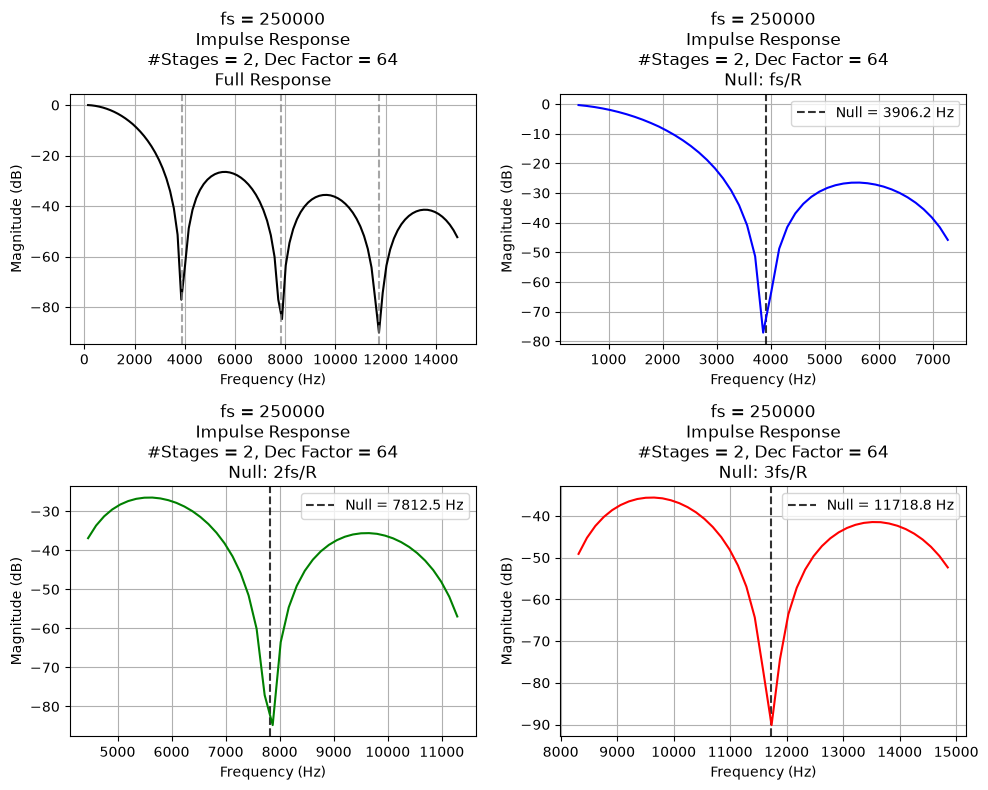

In [41]:
impulse_db = 20 * np.log10(np.maximum(np.abs(gain) / np.max(np.abs(gain)), 1e-12))
freq = np.asarray(freq)

start_from = 1 # To cut off any outlier data at DC

delta_freq = 3500
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axs[0,0].plot(freq[start_from:], impulse_db[start_from:], color='k', label='Full')
axs[0,0].set_xlabel("Frequency (Hz)")
axs[0,0].set_ylabel("Magnitude (dB)")
axs[0,0].set_title(f"fs = {fs}\nImpulse Response\n#Stages = {N}, Dec Factor = {R}\nFull Response")
axs[0,0].grid()

for k in range(1, 4):
    f_null = k * fs / R
    axs[0,0].axvline(
        f_null,
        color='gray',
        linestyle='--',
        alpha=0.7,
        label=f'{k}fs/R' if k == 1 else None
    )

null_freq = fs / R

axs[0,1].axvline(
    null_freq,
    color='k',
    linestyle='--',
    alpha=0.8,
    label=f'Null = {null_freq:.1f} Hz'
)
axs[0,1].legend()

mask = (freq >= null_freq - delta_freq) & \
       (freq <= null_freq + delta_freq)

axs[0,1].plot(freq[mask], 
              impulse_db[mask], 
              color='b', 
              label='Null: fs/R')
axs[0,1].set_xlabel("Frequency (Hz)")
axs[0,1].set_ylabel("Magnitude (dB)")
axs[0,1].set_title(f"fs = {fs}\nImpulse Response\n#Stages = {N}, Dec Factor = {R}\nNull: fs/R")
axs[0,1].grid()

null_freq = 2 * fs / R

axs[1,0].axvline(
    null_freq,
    color='k',
    linestyle='--',
    alpha=0.8,
    label=f'Null = {null_freq:.1f} Hz'
)
axs[1,0].legend()

mask = (freq >= null_freq - delta_freq) & \
       (freq <= null_freq + delta_freq)

axs[1,0].plot(freq[mask], 
              impulse_db[mask], 
              color='g', 
              label='Null: 2fs/R')
axs[1,0].set_xlabel("Frequency (Hz)")
axs[1,0].set_ylabel("Magnitude (dB)")
axs[1,0].set_title(f"fs = {fs}\nImpulse Response\n#Stages = {N}, Dec Factor = {R}\nNull: 2fs/R")
axs[1,0].grid()

null_freq = 3 * fs / R

axs[1,1].axvline(
    null_freq,
    color='k',
    linestyle='--',
    alpha=0.8,
    label=f'Null = {null_freq:.1f} Hz'
)
axs[1,1].legend()

mask = (freq >= null_freq - delta_freq) & \
       (freq <= null_freq + delta_freq)

axs[1,1].plot(freq[mask], 
              impulse_db[mask], 
              color='r', 
              label='Null: 3fs/R')
axs[1,1].set_xlabel("Frequency (Hz)")
axs[1,1].set_ylabel("Magnitude (dB)")
axs[1,1].set_title(f"fs = {fs}\nImpulse Response\n#Stages = {N}, Dec Factor = {R}\nNull: 3fs/R")
axs[1,1].grid()

plt.tight_layout()
plt.show()